# Official embedding experiments

Official series: threshold **0.4**, `candidate_limit=20000`, intersection boards, seeds **0–29** (30 boards).

Nine methods: the original six (W2V→W2V, FT→FT, W2V→FT, FT→W2V, concat→FT, concat→W2V) plus concat guesser (W2V→concat, FT→concat, concat→concat).

Three board types: `regular` (no dual), `dual` (all dual), `union` (mix).

No Stephenson score. Losses are shown as counts; mean turns are **wins only**.

Re-run all cells after new logs. Hyperparameter recaps stay in `inspect_embedding_game.ipynb`.

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "codenames" / "board.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import codenames.summarize_embedding as summarize_embedding

importlib.reload(summarize_embedding)
from codenames.summarize_embedding import (
    BOARD_TYPES,
    METHOD_LABELS,
    OFFICIAL_EXPECTED,
    OFFICIAL_MODELS,
    load_embedding_games,
    official_series,
)

RESULTS = ROOT / "results" / "embedding"
METHODS = [METHOD_LABELS[m] for m in OFFICIAL_MODELS]
BOARDS = list(BOARD_TYPES)
WIN_COLOR = "#2ca02c"
ASSASSIN_COLOR = "#d62728"
OTHER_COLOR = "#7f7f7f"

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df = pd.DataFrame(official_series(load_embedding_games(RESULTS)))
print("repo:", ROOT)
print("official games logged:", len(df), "/", OFFICIAL_EXPECTED)
if not df.empty:
    df["method"] = pd.Categorical(df["method"], categories=METHODS, ordered=True)
    df["board"] = pd.Categorical(df["board"], categories=BOARDS, ordered=True)

repo: /Users/sharons/personal-projects/nlp_project_reichman
official games logged: 801 / 810


## Coverage

Expected 30 games per method × board type. Empty cells are not yet run, or had no safe clue (union seed 3, fastText CM, on the starter).

In [2]:
def show_table(frame: pd.DataFrame) -> None:
    display(HTML(f'<div style="max-height:none;overflow:visible">{frame.to_html(escape=True)}</div>'))


if df.empty:
    print("No official games yet.")
else:
    coverage = (
        df.groupby(["method", "board"], observed=False)
        .size()
        .unstack("board")
        .reindex(index=METHODS, columns=BOARDS)
        .fillna(0)
        .astype(int)
    )
    display(Markdown("Games logged (max 30)"))
    show_table(coverage)
    wins = df.groupby(["method", "board"], observed=False)["win"].sum().unstack("board")
    wins = wins.reindex(index=METHODS, columns=BOARDS).fillna(0).astype(int)
    display(Markdown("Wins"))
    show_table(wins)

Games logged (max 30)

board,regular,dual,union
method,,,
W2V→W2V,30,30,30
FT→FT,29,30,28
W2V→FT,30,30,30
FT→W2V,29,30,28
concat→FT,30,30,30
concat→W2V,30,30,30
W2V→concat,30,30,30
FT→concat,29,30,28
concat→concat,30,30,30


Wins

board,regular,dual,union
method,,,
W2V→W2V,30,30,30
FT→FT,29,30,28
W2V→FT,23,18,23
FT→W2V,24,24,24
concat→FT,28,29,30
concat→W2V,30,29,30
W2V→concat,27,29,27
FT→concat,29,29,26
concat→concat,30,30,30


## Pair summary (played games)

Official series pooled across regular, dual, and union. Unplayable games (no safe clue) are not logged and are not in the denominator.

**Opp.** = blue cards hit; **Civ.** = civilian cards hit; **Clues** = turns; **Guesses** = guesses per clue; **SD** = standard deviation across games. **Mean w/o loss** = mean turns among wins. **Loss** = assassin hits among played games.


In [ ]:
from statistics import mean, stdev

from codenames.summarize_embedding import (
    INTERSECTION_MARK,
    board_type_from_wordpool,
    latest_per_condition,
)

raw = latest_per_condition(load_embedding_games(RESULTS))


def _mean_sd(xs):
    xs = list(xs)
    if not xs:
        return float("nan"), float("nan")
    if len(xs) == 1:
        return xs[0], 0.0
    return mean(xs), stdev(xs)


def _fmt_pct(x):
    return f"{x:.1f}%"


def _fmt_mean_sd(m, s):
    return f"{m:.2f} ({s:.2f})"


def _is_official(game):
    params = game.get("model_params") or {}
    wordpool = game.get("wordpool") or ""
    return (
        game.get("model") in OFFICIAL_MODELS
        and params.get("threshold") == 0.4
        and params.get("candidate_limit") in (None, 20_000)
        and INTERSECTION_MARK in wordpool
        and board_type_from_wordpool(wordpool) in BOARDS
        and game.get("seed") in range(30)
    )


rows = []
# Group by codemaster: W2V (all three guessers), then FT, then concat.
PAIR_TABLE_MODELS = (
    "word2vec",
    "word2vec->fasttext",
    "word2vec->concat",
    "fasttext",
    "fasttext->word2vec",
    "fasttext->concat",
    "concat->concat",
    "concat->word2vec",
    "concat->fasttext",
)
for model in PAIR_TABLE_MODELS:
    batch = [g for g in raw if g.get("model") == model and _is_official(g)]
    played = batch

    wins = [g for g in played if g.get("outcome") == "win"]
    losses = [g for g in played if g.get("outcome") == "assassin"]
    n_played = len(played)

    guesses_per_clue = []
    for g in played:
        turns = g.get("turns") or []
        n_guesses = sum(len(t.get("guesses") or []) for t in turns)
        guesses_per_clue.append(n_guesses / max(len(turns), 1))

    mean_wo, _ = _mean_sd(g["num_turns"] for g in wins)
    opp_m, opp_s = _mean_sd(g.get("blue_revealed") or 0 for g in played)
    civ_m, civ_s = _mean_sd(g.get("civilian_revealed") or 0 for g in played)
    clue_m, clue_s = _mean_sd(g["num_turns"] for g in played)
    g_m, g_s = _mean_sd(guesses_per_clue)

    rows.append(
        {
            "Model pair": METHOD_LABELS[model],
            "Loss": _fmt_pct(100 * len(losses) / n_played if n_played else 0),
            "Mean w/o loss": f"{mean_wo:.2f}",
            "Opp. (SD)": _fmt_mean_sd(opp_m, opp_s),
            "Civ. (SD)": _fmt_mean_sd(civ_m, civ_s),
            "Clues (SD)": _fmt_mean_sd(clue_m, clue_s),
            "Guesses (SD)": _fmt_mean_sd(g_m, g_s),
        }
    )

pair_table = pd.DataFrame(rows)
display(
    pair_table.style.hide(axis="index").set_table_styles(
        [
            {
                "selector": "th",
                "props": [("text-align", "center"), ("border-bottom", "1px solid black")],
            },
            {"selector": "td", "props": [("text-align", "center")]},
            {
                "selector": "tr:last-child td",
                "props": [("border-bottom", "1px solid black")],
            },
        ]
    )
)


## Wins and losses by method

Stacked bars: win (green), assassin (red), other loss (gray). One panel per board type.

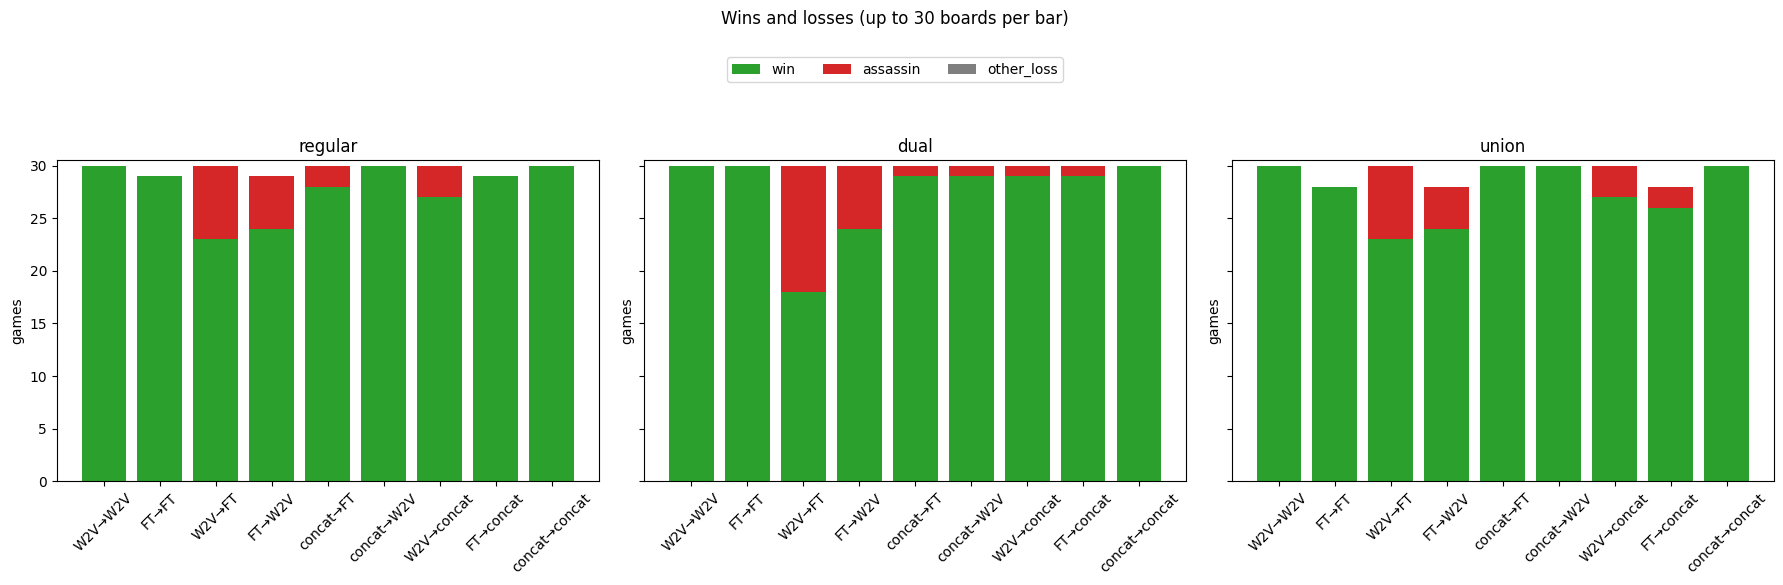

In [3]:
if df.empty:
    print("No official games yet.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    kinds = ["win", "assassin", "other_loss"]
    colors = {"win": WIN_COLOR, "assassin": ASSASSIN_COLOR, "other_loss": OTHER_COLOR}
    for ax, board in zip(axes, BOARDS):
        sub = df[df["board"] == board]
        counts = (
            sub.groupby(["method", "loss_kind"], observed=False)
            .size()
            .unstack("loss_kind")
            .reindex(index=METHODS, columns=kinds)
            .fillna(0)
        )
        bottom = None
        for kind in kinds:
            vals = counts[kind] if kind in counts.columns else 0
            ax.bar(METHODS, vals, bottom=bottom, color=colors[kind], label=kind)
            bottom = vals if bottom is None else bottom + vals
        ax.set_title(board)
        ax.set_ylim(0, 30.5)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel("games")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
    fig.suptitle("Wins and losses (up to 30 boards per bar)", y=1.16)
    fig.tight_layout()
    plt.show()

## Mean turns among wins

Method × board type. Empty / blank means no wins logged yet for that cell.

Mean turns on winning games

board,regular,dual,union
method,,,
W2V→W2V,3.37,3.67,3.40
FT→FT,7.93,8.00,8.00
W2V→FT,6.65,6.50,6.57
FT→W2V,9.33,9.42,8.96
concat→FT,6.21,6.55,6.27
concat→W2V,6.07,6.52,6.23
W2V→concat,4.22,4.14,4.04
FT→concat,8.28,8.24,8.08
concat→concat,5.73,6.17,5.90


Number of wins in that mean

board,regular,dual,union
method,,,
W2V→W2V,30,30,30
FT→FT,29,30,28
W2V→FT,23,18,23
FT→W2V,24,24,24
concat→FT,28,29,30
concat→W2V,30,29,30
W2V→concat,27,29,27
FT→concat,29,29,26
concat→concat,30,30,30


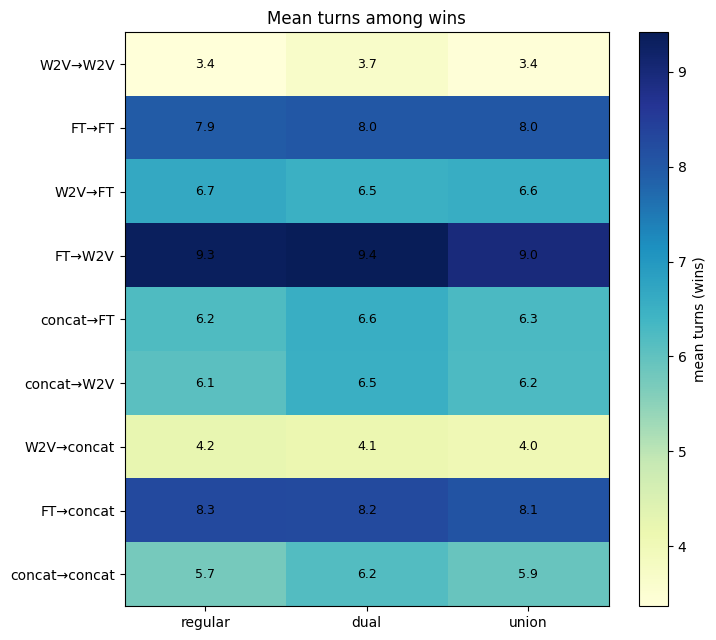

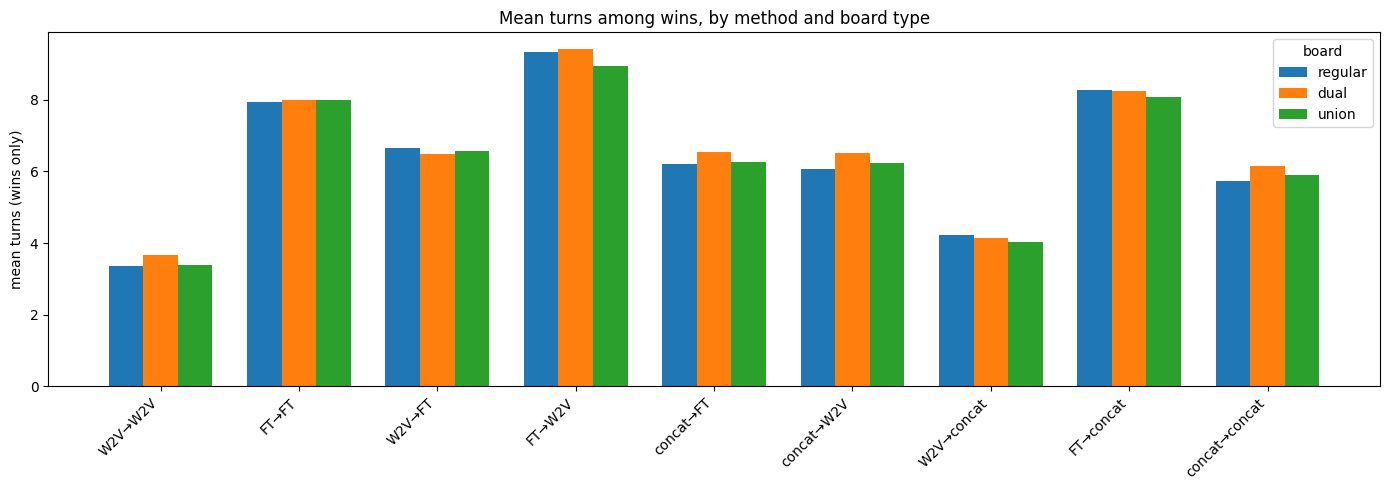

In [4]:
if df.empty or not df["win"].any():
    print("No wins logged yet.")
else:
    won = df[df["win"]]
    mean_turns = (
        won.groupby(["method", "board"], observed=False)["turns"]
        .mean()
        .unstack("board")
        .reindex(index=METHODS, columns=BOARDS)
    )
    n_wins = (
        won.groupby(["method", "board"], observed=False)["turns"]
        .count()
        .unstack("board")
        .reindex(index=METHODS, columns=BOARDS)
    )
    display(Markdown("Mean turns on winning games"))
    show_table(mean_turns.round(2))
    display(Markdown("Number of wins in that mean"))
    show_table(n_wins.fillna(0).astype(int))

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    grid = mean_turns.to_numpy(dtype=float)
    im = ax.imshow(grid, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(len(BOARDS)), BOARDS)
    ax.set_yticks(range(len(METHODS)), METHODS)
    ax.set_title("Mean turns among wins")
    for i in range(len(METHODS)):
        for j in range(len(BOARDS)):
            val = grid[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, label="mean turns (wins)")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(METHODS))
    width = 0.25
    for i, board in enumerate(BOARDS):
        vals = mean_turns[board].to_numpy(dtype=float) if board in mean_turns.columns else [float("nan")] * len(METHODS)
        ax.bar([p + (i - 1) * width for p in x], vals, width=width, label=board)
    ax.set_xticks(list(x), METHODS, rotation=45, ha="right")
    ax.set_ylabel("mean turns (wins only)")
    ax.set_title("Mean turns among wins, by method and board type")
    ax.legend(title="board")
    fig.tight_layout()
    plt.show()

## Extra: turn spread and clue size among wins

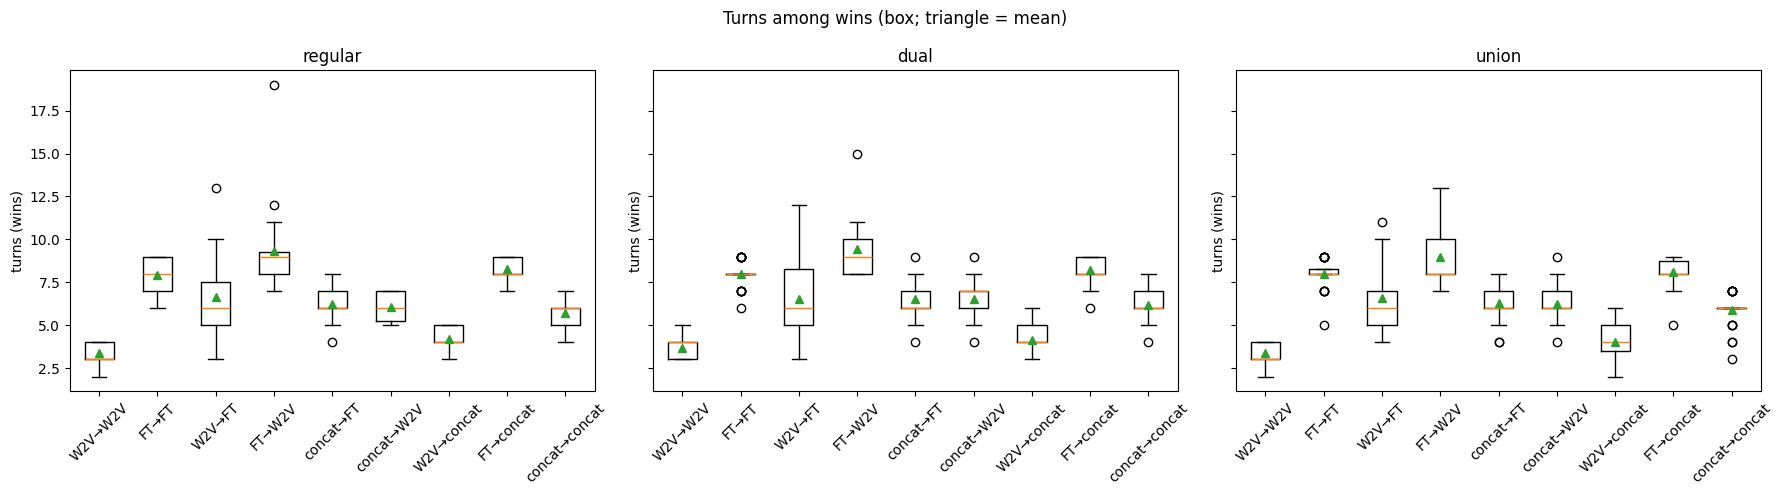

Mean clue number on winning games (larger = more aggressive groups)

board,regular,dual,union
method,,,
W2V→W2V,2.75,2.51,2.72
FT→FT,1.15,1.14,1.14
W2V→FT,2.63,2.60,2.86
FT→W2V,1.18,1.12,1.13
concat→FT,1.61,1.48,1.59
concat→W2V,1.61,1.51,1.55
W2V→concat,2.67,2.55,2.73
FT→concat,1.13,1.13,1.13
concat→concat,1.61,1.49,1.58


In [4]:
if df.empty or not df["win"].any():
    print("No wins logged yet.")
else:
    won = df[df["win"]]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, board in zip(axes, BOARDS):
        sub = won[won["board"] == board]
        data = [sub.loc[sub["method"] == m, "turns"].tolist() for m in METHODS]
        ax.boxplot(data, tick_labels=METHODS, showmeans=True)
        ax.set_title(board)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel("turns (wins)")
    fig.suptitle("Turns among wins (box; triangle = mean)")
    fig.tight_layout()
    plt.show()

    clue = (
        won.groupby(["method", "board"], observed=False)["mean_clue_n"]
        .mean()
        .unstack("board")
        .reindex(index=METHODS, columns=BOARDS)
    )
    display(Markdown("Mean clue number on winning games (larger = more aggressive groups)"))
    show_table(clue.round(2))